# 量子图像的灵活表示（Flexible Representation of Quantum Images，FRQI）

图像处理在面部识别和自动驾驶等快速增长的市场中得到了广泛应用。与此同时，量子图像处理作为量子信息科学的一个新兴领域，有望在特定但常用的操作（如边缘检测）上获得显著的速度提升。例如，Zhang等人在2014年提出了一种基于量子图像灵活表示（FRQI）和传统Sobel边缘提取算法的新型量子图像边缘提取算法（QSobel）[3]。对于大小为 $2^{n} × 2^{n}$ 的FRQI量子图像，QSobel可以在 $O(n^{2})$ 的计算复杂度内提取边缘，与现有的边缘提取算法相比，这是一个显著的指数级加速。

本章将介绍量子图像灵活表示(FRQI) [1]。一旦将图像编码为这些态，就可以使用其他量子算法（如QSobel边缘提取算法）进行处理，但本文只涉及编码部分 [2]。

## 1. FRQI态

表示图像的量子态为：

$$
\begin{equation}
    \ket{I(\theta)} = \frac{1}{2^n} \sum_{i=0}^{2^{2n}-1} \left( \cos \theta_i \ket{0} + \sin \theta_i \ket{1} \right) \otimes \ket{i}
\end{equation}
$$

其中，

$$
\begin{equation}
    \theta_i \in \left[0, \frac{\pi}{2}\right], \quad i = 0, 1, \dots, 2^{2n}-1
\end{equation}
$$

FRQI态是一个归一化的态，从公式可以看出 $\left\|I(\theta)\right\|=1$ 。它由两部分组成：

* 颜色信息编码: $\cos\theta_{i}\ket{0}+\sin\theta_{i}\ket{1}$ 
* 相关像素位置编码: $\ket{i}$

下面给出一个 $2\times2$ 图像的简单示例，其中包含相应的 $\theta$ 角(颜色编码)和相关的态矢(位置编码)：

$$
\begin{array}{|c|c|}
\hline
\theta_{0},\ket{00} & \theta_{1},\ket{01}  \\
\hline
\theta_{2},\ket{10} & \theta_{3},\ket{11} \\
\hline
\end{array}
$$

其等价的量子态为：

$$
\begin{aligned}
\ket{I}=\frac{1}{2}[ \; & \phantom{+} \left(\cos\theta_{0}\ket{0}+\sin\theta_{0}\ket{1} \right)\otimes\ket{00}&\\
& + \left(\cos\theta_{1}\ket{0}+\sin\theta_{1}\ket{1} \right)\otimes\ket{01} \\
& + \left(\cos\theta_{2}\ket{0}+\sin\theta_{2}\ket{1} \right)\otimes\ket{10}\\
& + \left(\cos\theta_{3}\ket{0}+\sin\theta_{3}\ket{1} \right)\otimes\ket{11} \;]
\end{aligned}
$$


## 2. 构建FRQI态：两步过程

从初始态 $\ket{0}^{\otimes2n+1}$ 到指定的FRQI态需要两个步骤 [1]，首先需要将系统置于全叠加态，除了最后一个用于编码颜色的量子比特。$H^{\otimes2n}$ 表示 $2n$ 个Hadamard操作的张量积，中间态为：

$$
\ket{H}=\frac{1}{2^{n} }\ket{0}\otimes\sum_{i=0}^{2^{2n}-1}\ket{i}=\mathcal{H}\left(\ket{0}^{\otimes2n+1}\right)
$$

存在一个幺正变换 $\mathcal{P}=\mathcal{RH}$ ，可以将初始态 $\ket{0}^{\otimes2n+1}$ 转化为FRQI态 $I(\theta)$ [1]：

$$
\mathcal{R}\ket{H}=\left(\prod_{i=0}^{2^{2n}-1}R_{i}\right)\ket{H}=\ket{I(\theta)}
\tag{2.2}
$$

$R_{i}$ 操作是受控旋转矩阵，定义为：

$$
R_{i}=\left( I\otimes \sum^{2^{2n}-1}_{j=0,j\neq i}\ket{j}\bra{j}\right) + R_{y}\left(2\theta_{i}\right)\otimes\ket{i}\bra{i} 
$$

其中， $R_{y}(2\theta_{i})$ 是标准旋转矩阵：

$$
R_{y}(2\theta_{i})=
\begin{pmatrix}
\cos\theta_{i} & -\sin\theta_{i}\\
\sin\theta_{i} & \cos\theta_{i} 
\end{pmatrix} 
$$

## 3. 实现和测量：带有灰度值的 $2\times2$ 图像 

我们使用灰度图像，这意味着只有一个值与颜色编码相关：强度。换句话说，所有的 $\theta_{i}$ 等于0意味着所有像素都是黑色的，如果所有的 $\theta_{i}$ 值都等于 $\pi/2$，那么所有像素都是白色的，依此类推。感兴趣的值是 $0,\pi/4和\pi/2$ 。

### 3.1 示例1：$\theta_{i}=0$ ; 所有像素强度最小

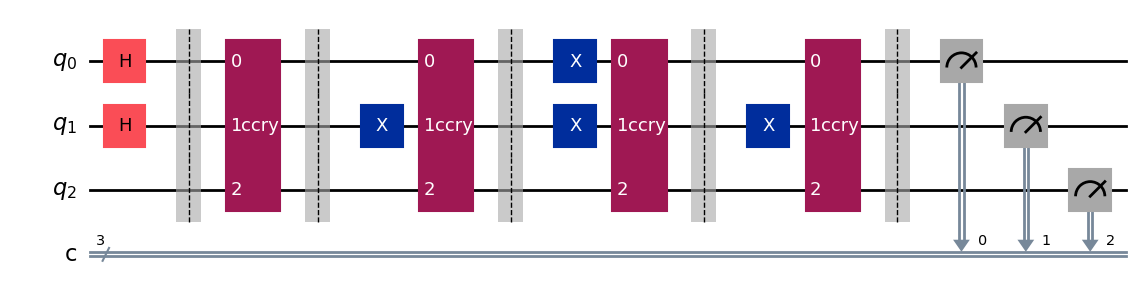

In [2]:
import deepquantum as dq
import numpy as np
import matplotlib.pyplot as plt

theta = 0

cir = dq.QubitCircuit(3)

cir.hlayer(wires=[0,1])

cir.barrier()
cir.ry(2,controls=[0,1], inputs=2*theta)
cir.barrier()

cir.x(1)
cir.ry(2,controls=[0,1], inputs=2*theta)
cir.barrier()

cir.x(0)
cir.x(1)
cir.ry(2,controls=[0,1], inputs=2*theta)
cir.barrier()

cir.x(1)
cir.ry(2,controls=[0,1], inputs=2*theta)
cir.barrier()

cir.measure()
cir.draw()


#### 3.1.1 测量和图像恢复

从FRQI态的公式中可以看出，由于 $\theta$ 的值，FRQI态中与态 $\ket{1}$ 相关的颜色编码部分的所有项都将消失，因此我们预期只会看到4个等概率的态。

{'000': (253, tensor(0.2500)), '010': (267, tensor(0.2500)), '110': (252, tensor(0.2500)), '100': (252, tensor(0.2500))}


<BarContainer object of 4 artists>

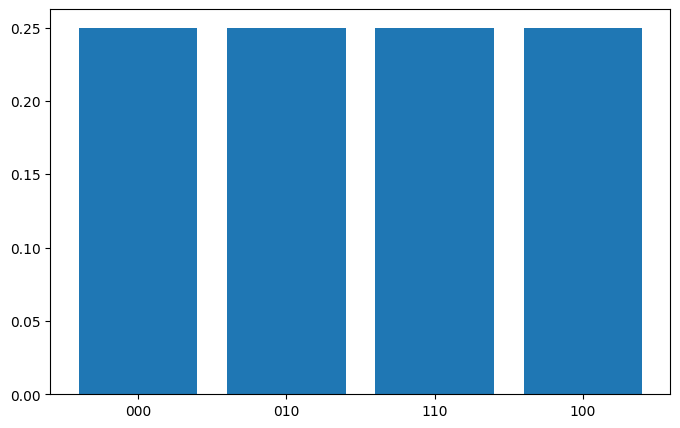

In [3]:
cir()

res=cir.measure(with_prob= True) # 打印测量结果
print(res)

# 将数据分解为X和Y轴的值
labels = list(res.keys())
values = [value[1] for value in res.values()]

# 创建条形图
plt.figure(figsize=(8, 5))  # 设置图形大小
plt.bar(labels, values)  # 绘制条形图

### 3.2 示例2: $\theta_{i}=\pi/2$ ; 所有像素强度最大

线路与第一个定义的相同，除了 $\theta$ 的值不同。

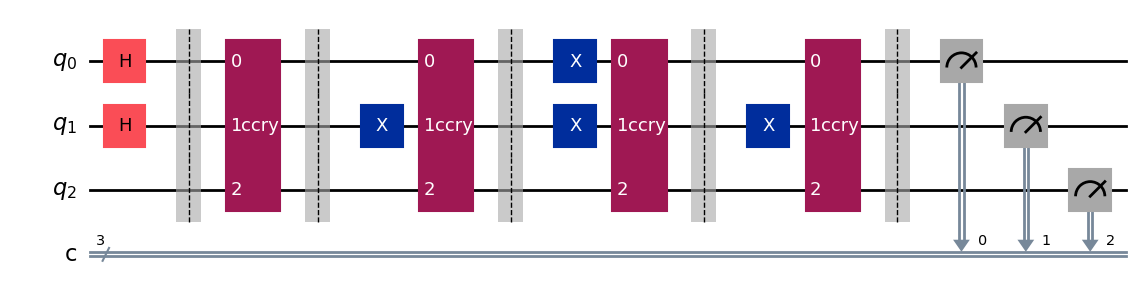

In [4]:
theta = np.pi/2

cir = dq.QubitCircuit(3)

cir.hlayer(wires=[0,1])

cir.barrier()
cir.ry(2,controls=[0,1], inputs=2*theta)
cir.barrier()

cir.x(1)
cir.ry(2,controls=[0,1], inputs=2*theta)
cir.barrier()

cir.x(0)
cir.x(1)
cir.ry(2,controls=[0,1], inputs=2*theta)
cir.barrier()

cir.x(1)
cir.ry(2,controls=[0,1], inputs=2*theta)
cir.barrier()

cir.measure()
cir.draw()

#### 3.2.1 测量和图像恢复

在这种情况下，从FRQI态的公式中可以看出，公式中与 $\cos$ 相关的项消失，得到4个等概率的态，前缀为"1"。

{'101': (251, tensor(0.2500)), '011': (239, tensor(0.2500)), '001': (279, tensor(0.2500)), '111': (255, tensor(0.2500))}


<BarContainer object of 4 artists>

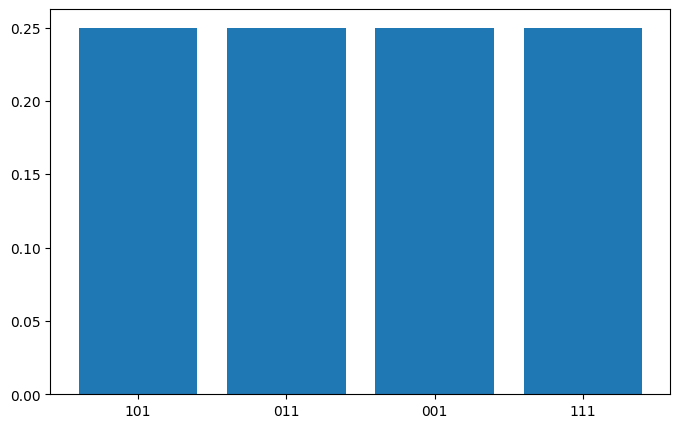

In [5]:
cir()

res=cir.measure(with_prob= True) # 打印测量结果
print(res)

# 将数据分解为X和Y轴的值
labels = list(res.keys())
values = [value[1] for value in res.values()]

# 创建条形图
plt.figure(figsize=(8, 5))  # 设置图形大小
plt.bar(labels, values)  # 绘制条形图

### 3.3 示例3: $\theta_{i}=\pi/4$ ; 所有像素强度为50%

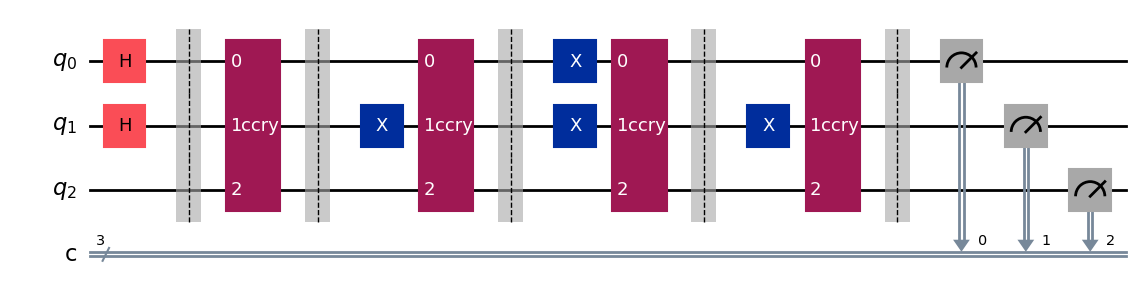

In [6]:
theta = np.pi/4

cir = dq.QubitCircuit(3)

cir.hlayer(wires=[0,1])

cir.barrier()
cir.ry(2,controls=[0,1], inputs=2*theta)
cir.barrier()

cir.x(1)
cir.ry(2,controls=[0,1], inputs=2*theta)
cir.barrier()

cir.x(0)
cir.x(1)
cir.ry(2,controls=[0,1], inputs=2*theta)
cir.barrier()

cir.x(1)
cir.ry(2,controls=[0,1], inputs=2*theta)
cir.barrier()

cir.measure()
cir.draw()

#### 3.3.1 测量和图像恢复

在这种情况下，我们预期得到所有8个等概率的态。

{'100': (118, tensor(0.1250)), '110': (143, tensor(0.1250)), '000': (119, tensor(0.1250)), '111': (138, tensor(0.1250)), '101': (139, tensor(0.1250)), '011': (139, tensor(0.1250)), '010': (107, tensor(0.1250)), '001': (121, tensor(0.1250))}


<BarContainer object of 8 artists>

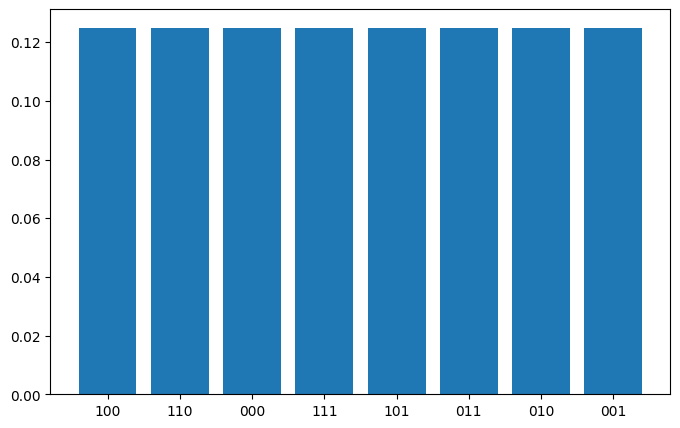

In [7]:
cir()

res=cir.measure(with_prob= True) # 打印测量结果
print(res)

# 将数据分解为X和Y轴的值
labels = list(res.keys())
values = [value[1] for value in res.values()]

# 创建条形图
plt.figure(figsize=(8, 5))  # 设置图形大小
plt.bar(labels, values)  # 绘制条形图

## 4. 线路压缩

随着我们想要编码的图像尺寸的增大，线路深度也会增大。为了减少线路的复杂性（深度），我们需要进行线路的压缩。

压缩可以通过将具有相同强度的像素分组来实现。它们之间的区别在于用于编码位置的二进制字符串，但它们共享相关控制旋转的相同角度。例如，让我们考虑一张 8x8 的2种蓝红颜色图像，蓝色像素的位置是 $\ket{0}, \ket{8}, \ket{16}, \ket{24}, \ket{32}, \ket{40}, \ket{48}$ 和 $\ket{56}$。

它们各自的二进制表示和布尔表达式是：

\begin{array}{|c|c|c|}
\hline
位置 & 二进制字符串 & 布尔表达式 \\
\hline 
\ket{0} &\ket{000000} & \overline{x_{5}}\overline{x_{4}}\overline{x_{3}}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}  \\
\hline
\ket{8} &\ket{001000} & \overline{x_{5}}\overline{x_{4}}x_{3}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}  \\
\hline
\ket{16} &\ket{010000} & \overline{x_{5}}x_{4}\overline{x_{3}}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}  \\
\hline  
\ket{24} &\ket{011000} & \overline{x_{5}}x_{4}x_{3}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}} \\
\hline
\ket{32} &\ket{100000} & x_{5}\overline{x_{4}}\overline{x_{3}}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}  \\
\hline
\ket{40} &\ket{101000} & x_{5}\overline{x_{4}}x_{3}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}  \\  
\hline
\ket{48} &\ket{110000} & x_{5}x_{4}\overline{x_{3}}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}  \\
\hline
\ket{56} &\ket{111000} & x_{5}x_{4}x_{3}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}  \\
\hline
\end{array}

我们想要简化的布尔表达式是：

$exp = \overline{x_{5}}\overline{x_{4}}\overline{x_{3}}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}+\overline{x_{5}}\overline{x_{4}}x_{3}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}+\overline{x_{5}}x_{4}\overline{x_{3}}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}+\overline{x_{5}}x_{4}x_{3}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}+x_{5}\overline{x_{4}}\overline{x_{3}}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}+x_{5}\overline{x_{4}}x_{3}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}+x_{5}x_{4}\overline{x_{3}}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}+x_{5}x_{4}x_{3}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}$  

\begin{align*}
exp&=(\overline{x_{5}}+x_{5})(\overline{x_{4}}\overline{x_{3}}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}} +\overline{x_{4}}x_{3}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}+x_{4}\overline{x_{3}}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}+x_{4}x_{3}\overline{x_{2}}\overline{x_{1}}\overline{x_{0}})\\     &=\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}(\overline{x_{4}}\overline{x_{3}}+\overline{x_{4}}x_{3}+x_{4}\overline{x_{3}}+x_{4}x_{3})\\   &=\overline{x_{2}}\overline{x_{1}}\overline{x_{0}}  
\end{align*}

我们不仅可以将像素组合在一个条件旋转下，而且还可以看到控制门的条件也被简化了，这将导致实现所需的线路深度减少。

## 参考文献

[1] Le, P.Q., Dong, F. & Hirota, K. A flexible representation of quantum images for polynomial preparation, image compression, and processing operations. Quantum Inf Process 10, 63–84 (2011). https://doi.org/10.1007/s11128-010-0177-y 

[2] Le, Phuc Quang, Fayang Dong and Kaoru Hirota. “Flexible Representation of Quantum Images and Its Computational Complexity Analysis.” (2009). https://doi.org/10.14864/fss.25.0.185.0

[3] Y. Zhang, K. Lu, and Y. Gao, Qsobel: A Novel Quantum Image Edge Extraction Algorithm, Sci. China Inf. Sci. 58, 1-13 (2015). http://engine.scichina.com/doi/pdf/62784e3238b8457bb36f42efc70b37d2